
# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

# Exercise 1

In [7]:
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt

N = 1000

X = np.linspace(0, 1, N+1)
h = X[1]-X[0]

Ua = 3-np.e
Ub = 0

A = np.zeros((N+1,N+1), float)

for i in range(1, N):
    A[i, i] = 2/h
    A[i-1, i] = -1/h
    A[i, i-1] = -1/h

A[0, 1] = 0
A[1, 0] = 0
A[0,0] = 1
A[N, N] = 1
A

array([[ 1.e+00,  0.e+00,  0.e+00, ...,  0.e+00,  0.e+00,  0.e+00],
       [ 0.e+00,  2.e+03, -1.e+03, ...,  0.e+00,  0.e+00,  0.e+00],
       [ 0.e+00, -1.e+03,  2.e+03, ...,  0.e+00,  0.e+00,  0.e+00],
       ...,
       [ 0.e+00,  0.e+00,  0.e+00, ...,  2.e+03, -1.e+03,  0.e+00],
       [ 0.e+00,  0.e+00,  0.e+00, ..., -1.e+03,  2.e+03,  0.e+00],
       [ 0.e+00,  0.e+00,  0.e+00, ...,  0.e+00,  0.e+00,  1.e+00]],
      shape=(1001, 1001))

In [13]:
def phi(x, xi):
    return np.maximum(0, 1 - np.abs(x - xi) / h)

B = np.zeros_like(X)

for i in range(1, N):
    a = max(0, X[i]-h)
    b = min(1, X[i]+h)
    B[i] = integrate.quad(
        lambda x: x*np.exp(x)*phi(x, X[i]), a, b
    )[0]

B[0] = Ua
B[1] += Ua/h

B[-2] += Ub/h
B[-1] = Ub

Alpha = np.linalg.solve(A, B)




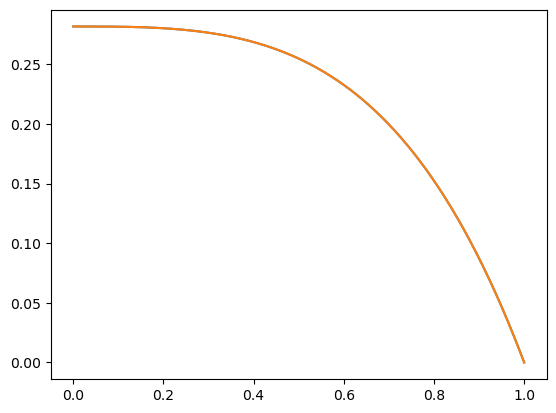

In [14]:
T = np.linspace(0, 1, 1000)

plt.plot(
    X,
    Alpha,
)

plt.plot(
    T,
    (lambda x: 1-np.e+np.exp(x)*(2-x)-x)(T)
)

# Exercise 2

In [2]:
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt


N = 1000

X = np.linspace(0, 1, N+1)
h = X[1]-X[0]

A = np.zeros((N+1, N+1), float)

for i in range(1, N):
    A[i, i] = 2/h
    A[i, i-1] = -1/h
    A[i-1, i] = -1/h

A[0,1] = 0
A[1,0] = 0
A[0,0] = 1
A[-1,-1] = 1
A

array([[ 1.e+00,  0.e+00,  0.e+00, ...,  0.e+00,  0.e+00,  0.e+00],
       [ 0.e+00,  2.e+03, -1.e+03, ...,  0.e+00,  0.e+00,  0.e+00],
       [ 0.e+00, -1.e+03,  2.e+03, ...,  0.e+00,  0.e+00,  0.e+00],
       ...,
       [ 0.e+00,  0.e+00,  0.e+00, ...,  2.e+03, -1.e+03,  0.e+00],
       [ 0.e+00,  0.e+00,  0.e+00, ..., -1.e+03,  2.e+03,  0.e+00],
       [ 0.e+00,  0.e+00,  0.e+00, ...,  0.e+00,  0.e+00,  1.e+00]],
      shape=(1001, 1001))

In [3]:
def phi(x, xi):
    return np.maximum(0, 1-np.abs(x-xi)/h)

B = np.zeros((N+1), float)

for i in range(1,N):
    a = np.maximum(0, X[i]-h)
    b = np.minimum(1, X[i]+h)
    B[i] = integrate.quad(
        (lambda x: np.sin(np.pi*x) * phi(x, X[i])),
        a, b
    )[0]

Alpha = np.linalg.solve(A, B)


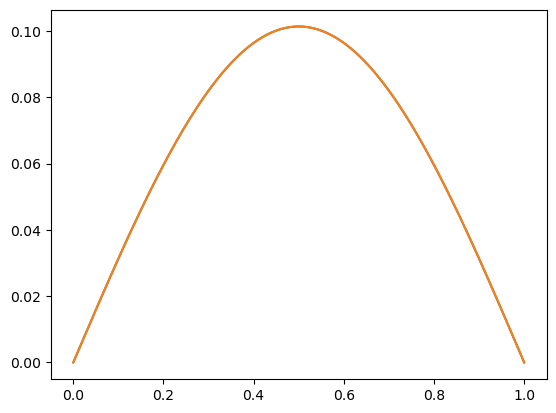

In [4]:
plt.plot(X, Alpha)

plt.plot(
    X,
    (lambda x: np.sin(np.pi*x)/(np.pi**2))(X)
)